## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("../data/processed")

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.0f}".format)

## Load data

In [2]:
daily_sales       = pd.read_csv(PROCESSED / "daily_sales.csv", parse_dates=["date"])
product_sales     = pd.read_csv(PROCESSED / "product_sales.csv")
inventory_daily   = pd.read_csv(PROCESSED / "inventory_daily.csv", parse_dates=["date"])
financial_summary = pd.read_csv(PROCESSED / "financial_summary.csv", parse_dates=["date"])

print("daily_sales      :", daily_sales.shape)
print("product_sales    :", product_sales.shape)
print("inventory_daily  :", inventory_daily.shape)
print("financial_summary:", financial_summary.shape)

daily_sales      : (31, 3)
product_sales    : (11, 8)
inventory_daily  : (19, 6)
financial_summary: (31, 6)


In [3]:
daily_sales.describe()

,date,total_revenue,total_transaksi
count,31,31,31
mean,2026-09-10 00:00:00,"246,532",3
min,2026-08-26 00:00:00,"7,000",1
25%,2026-09-02 12:00:00,"57,000",2
50%,2026-09-10 00:00:00,"214,000",3
75%,2026-09-17 12:00:00,"384,250",4
max,2026-09-25 00:00:00,"701,500",5
std,NaN,"208,284",1


## Tren Penjualan Harian

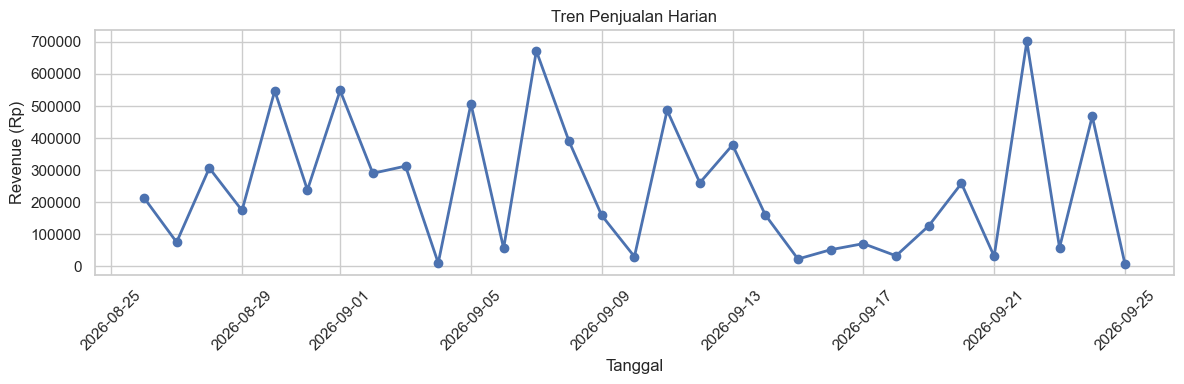

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_sales["date"], daily_sales["total_revenue"], marker="o", linewidth=2)
ax.set_title("Tren Penjualan Harian")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Revenue (Rp)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Produk Terlaris by Revenue

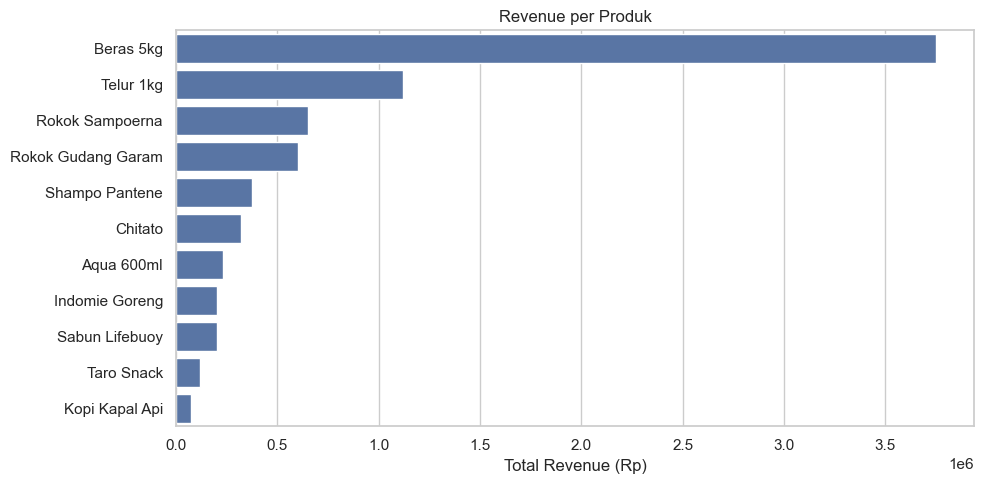

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=product_sales.sort_values("total_revenue", ascending=False),
    x="total_revenue", y="name", ax=ax
)
ax.set_title("Revenue per Produk")
ax.set_xlabel("Total Revenue (Rp)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Margin Per Produk

C:\Users\Tigro\AppData\Local\Temp\ipykernel_20296\2716041873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


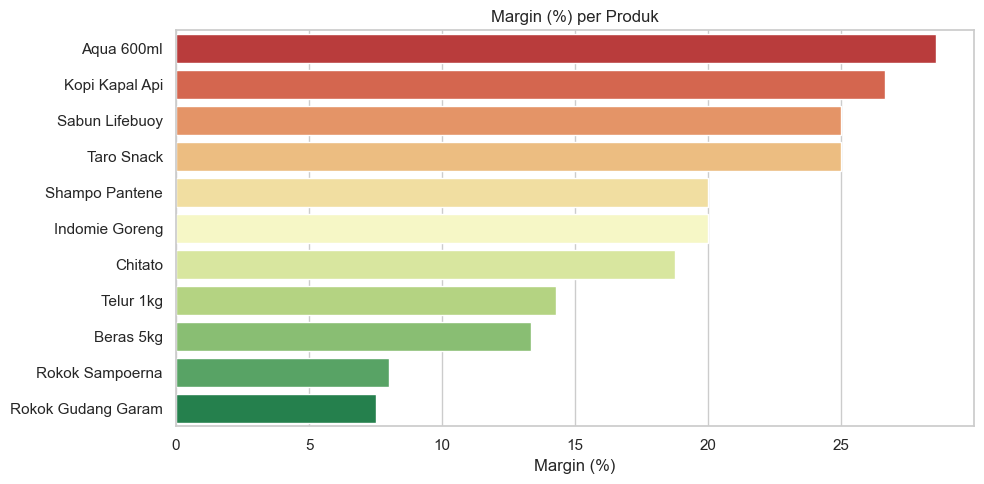

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=product_sales.sort_values("margin_pct", ascending=False),
    x="margin_pct", y="name", ax=ax, palette="RdYlGn"
)
ax.set_title("Margin (%) per Produk")
ax.set_xlabel("Margin (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Laba Harian

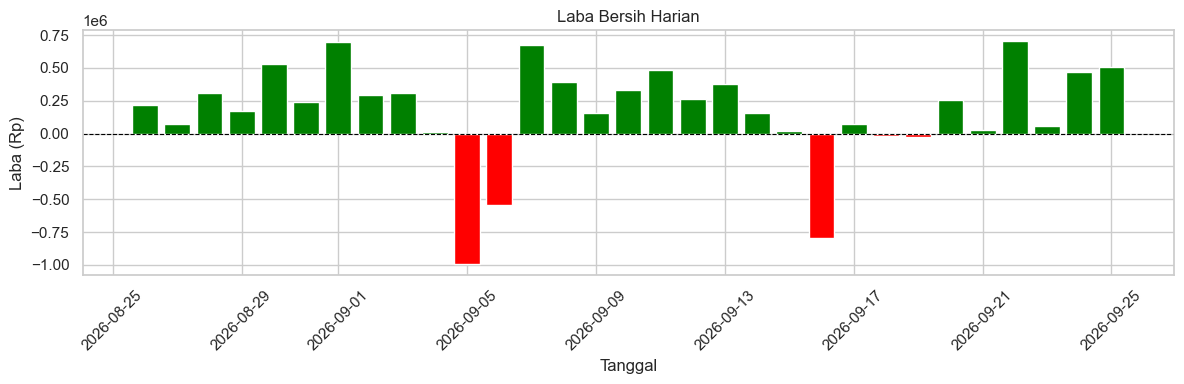

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(financial_summary["date"], financial_summary["laba_bersih"],
       color=["green" if x >= 0 else "red" for x in financial_summary["laba_bersih"]])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Laba Bersih Harian")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Laba (Rp)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Summery Keuangan

In [8]:
print("=== RINGKASAN KEUANGAN 30 HARI ===")
print(f"Total Revenue    : Rp{financial_summary['revenue'].sum():>15,.0f}")
print(f"Total Pengeluaran: Rp{financial_summary['expense'].sum():>15,.0f}")
print(f"Pemasukan Lain   : Rp{financial_summary['income_lain'].sum():>15,.0f}")
print(f"Laba Bersih      : Rp{financial_summary['laba_bersih'].sum():>15,.0f}")

=== RINGKASAN KEUANGAN 30 HARI ===
Total Revenue    : Rp      7,642,500
Total Pengeluaran: Rp      3,165,000
Pemasukan Lain   : Rp        950,000
Laba Bersih      : Rp      5,427,500
